In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /mnt/c/Research/LLMAgora


In [2]:
# ── Full group-level analysis (mean ± std across all repeats) ─────────────────
import matplotlib.pyplot as plt
%matplotlib inline

from agora.sweep_results import SweepManifest
from agora.experiment import SEMANTIC_ANALYSIS_METRICS, SEMANTIC_SIMILARITY_METHOD_COSINE
from agora.semantic_similarity_analyzer import DEFAULT_COSINE_MODEL_NAME
from agora.persona_adherence_evaluator import PERSONA_ANALYSIS_METRICS
from agora.emotion_analyzer import PUBLIC_NARRATIVE_FIELD, PRIVATE_NARRATIVE_FIELD

manifest = SweepManifest.from_path("outputs/sweeps_2/manifest.json")

# Run all analyses on every repeat of one experiment group
group_result = manifest[3].run_analysis(
    manifest.sweep_root,
    semantic_analysis_metrics=list(SEMANTIC_ANALYSIS_METRICS),
    semantic_similarity_method=SEMANTIC_SIMILARITY_METHOD_COSINE,
    semantic_similarity_model=DEFAULT_COSINE_MODEL_NAME,
    persona_analysis_metrics=list(PERSONA_ANALYSIS_METRICS),
    persona_scoring_model="anthropic/claude-sonnet-4.6",
    persona_score_samples=3,
)

/home/snoroozi/anaconda3/envs/agora_eval/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cosine model: all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# ── 1. Text summary ───────────────────────────────────────────────────────────
group_result.summary()

EXPERIMENT GROUP SUMMARY
  Fingerprint : 7acc8120bbb0c4b6…
  Repeats     : 2
  Agent α     : Alpha
  Agent β     : Beta

----------------------------------------------------------------
SEMANTIC SIMILARITY  (mean ± SE across repeats, averaged over turns)
----------------------------------------------------------------

● Self-Consistency
    Alpha                           mean=0.456  ±0.022
    Beta                            mean=0.812  ±0.029

● Cross-Agent Public Alignment
    mean=0.714  ±0.032

● Cross-Agent Private Alignment
    mean=0.438  ±0.005

----------------------------------------------------------------
PERSONA ADHERENCE  (mean ± SE across repeats)
----------------------------------------------------------------

● Alpha  (metrics: ['full_debate_private', 'full_debate_public', 'private_cumulative', 'private_per_turn', 'public_cumulative', 'public_per_turn'])
    Full-debate public       : mean=2.000  ±0.000
    Full-debate private      : mean=4.000  ±0.000

● Beta  (met

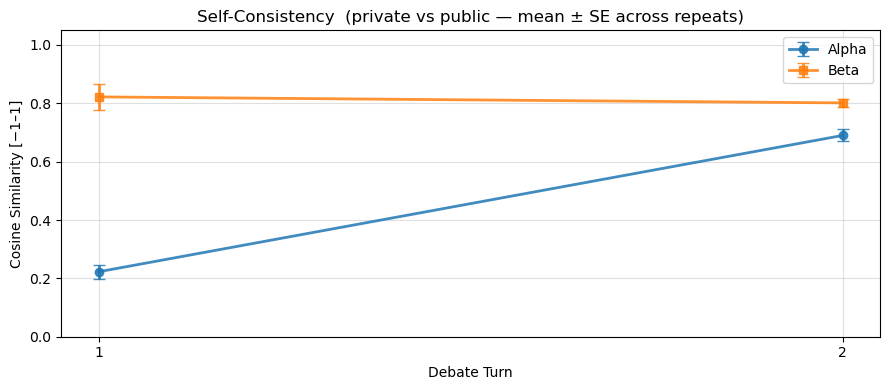

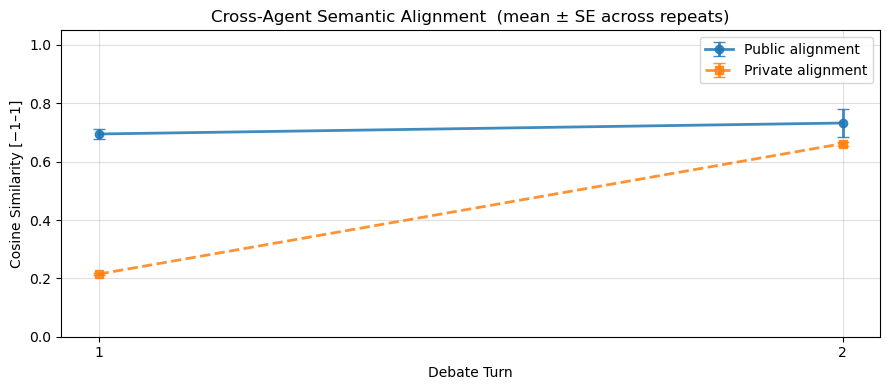

In [4]:
# ── 2. Semantic similarity (error bars across repeats) ────────────────────────
group_result.plot_semantic()

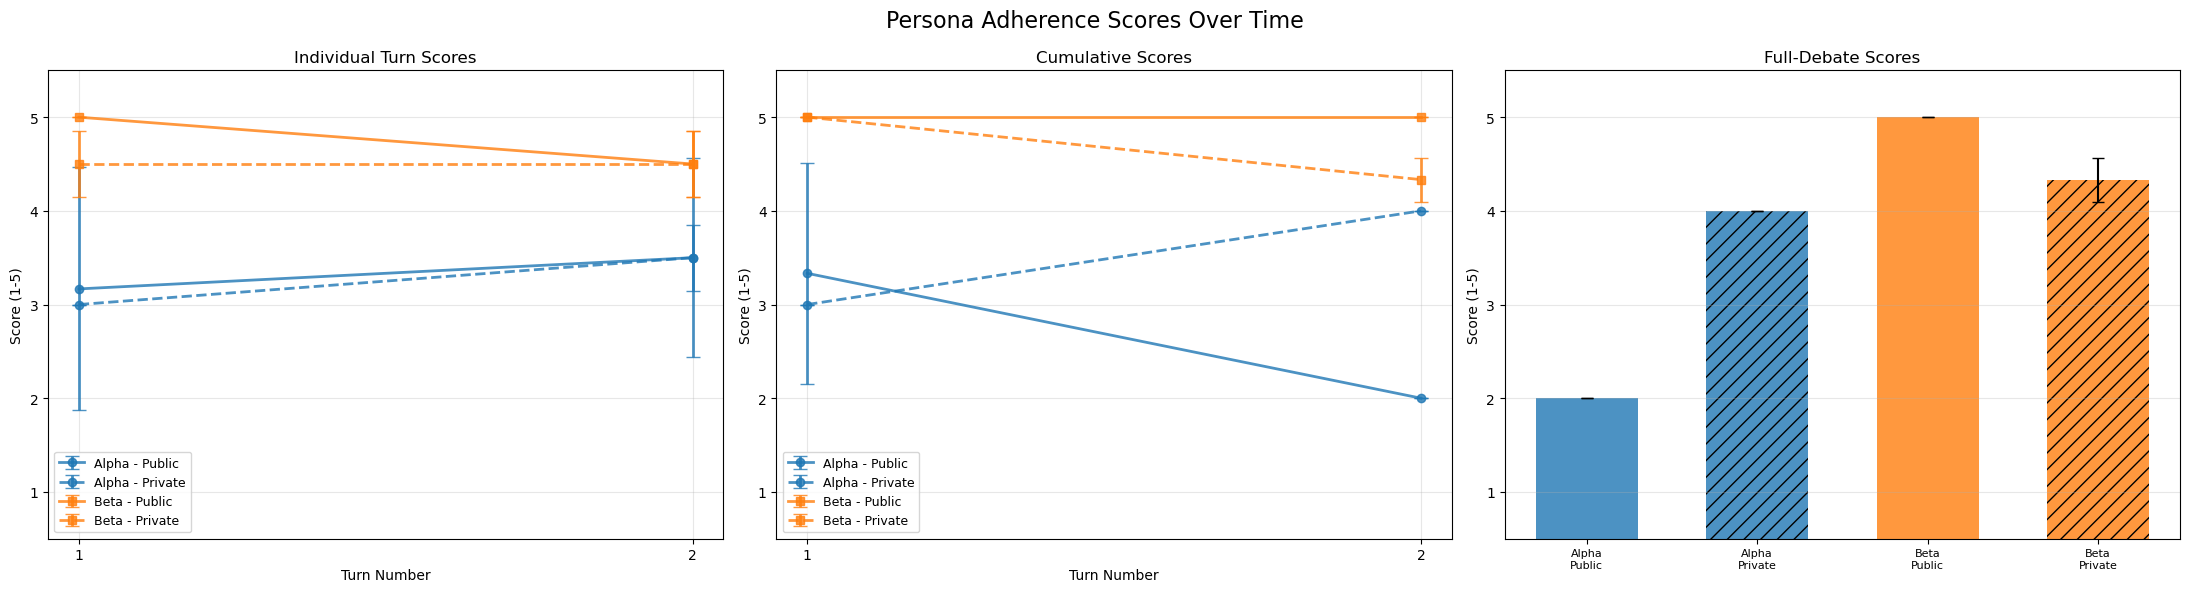

In [5]:
# ── 3. Persona adherence (error bars across repeats) ─────────────────────────
group_result.plot_persona()

Loading nli model: dleemiller/finecat-nli-l...


Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

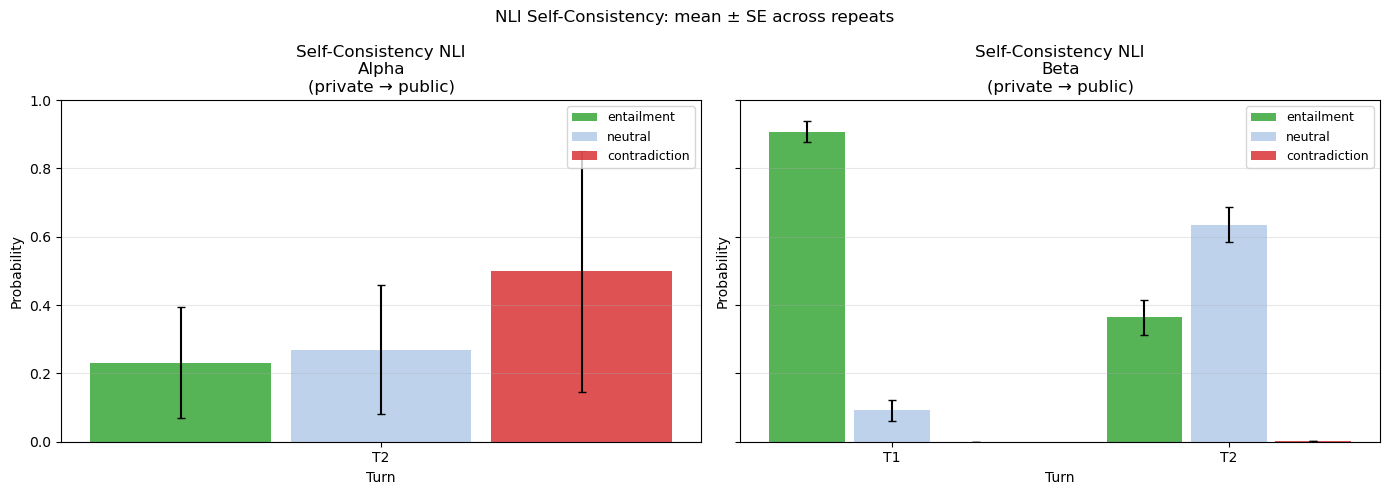

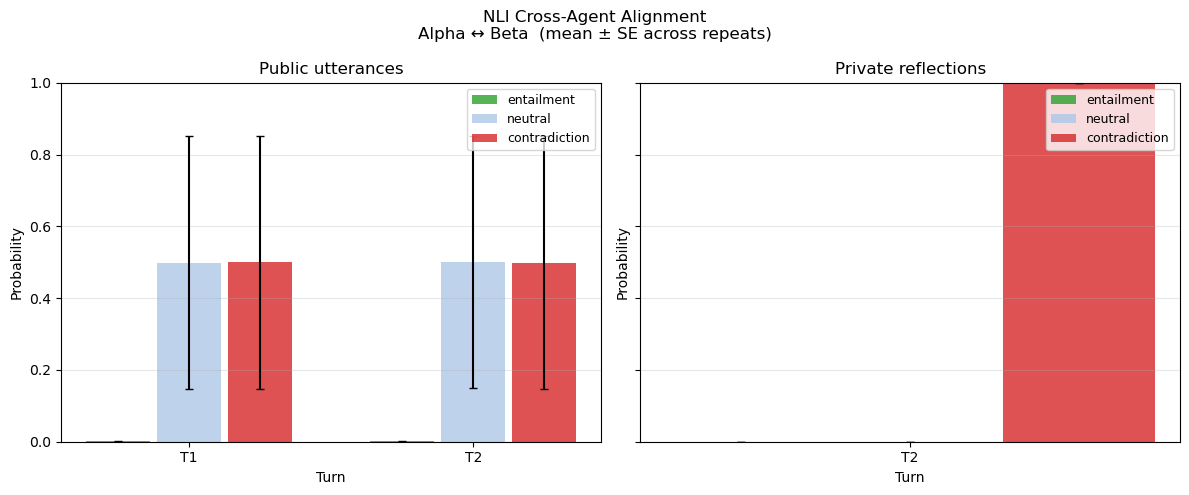

In [6]:
# ── 4. NLI distributions (mean ± se shaded bands) ────────────────────────────
group_result.plot_nli()

The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.


Loading emotion model: cirimus/modernbert-base-emotions...


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Loading emotion model: cirimus/modernbert-base-emotions...


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

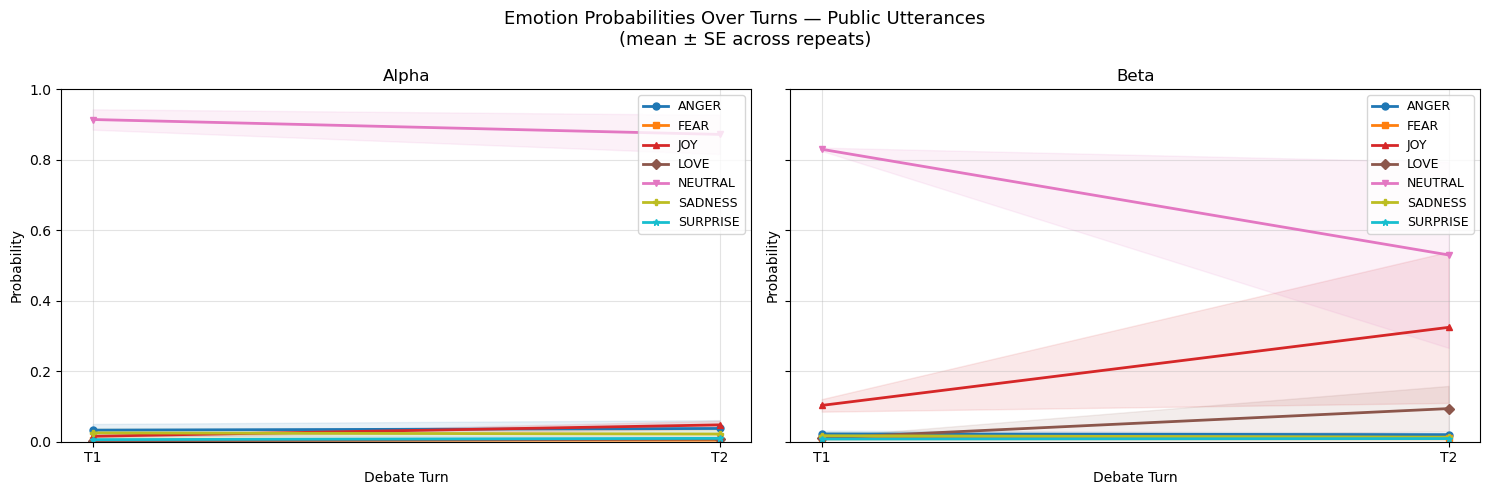

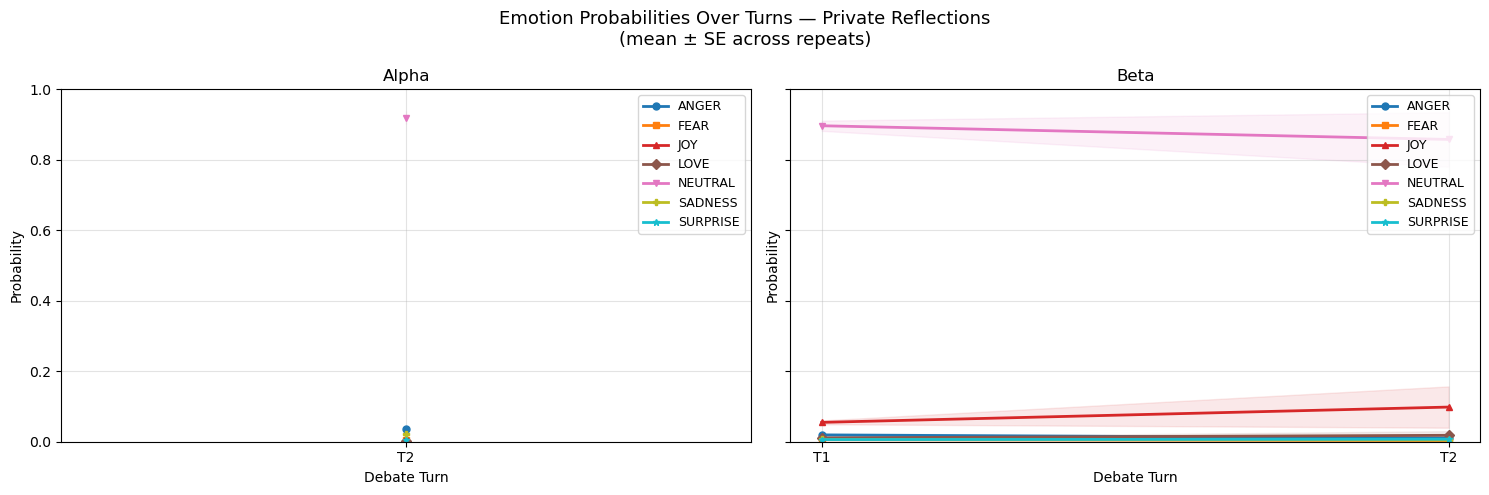

In [7]:
# ── 5. Emotion analysis (mean ± 1σ shaded bands, synced legend) ──────────────
group_result.plot_emotions(PUBLIC_NARRATIVE_FIELD)
group_result.plot_emotions(PRIVATE_NARRATIVE_FIELD)

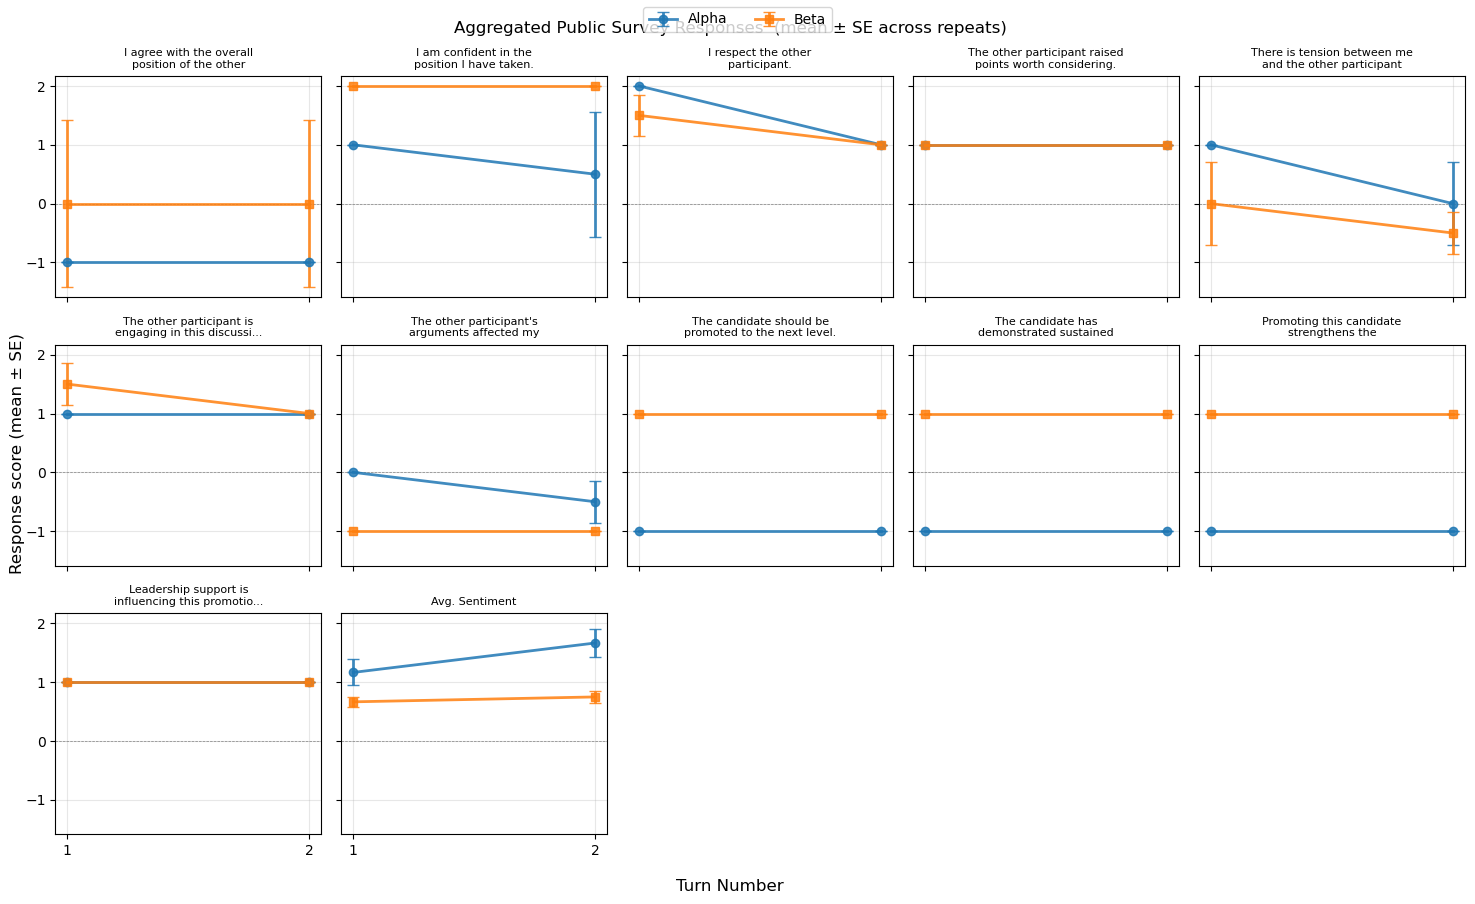

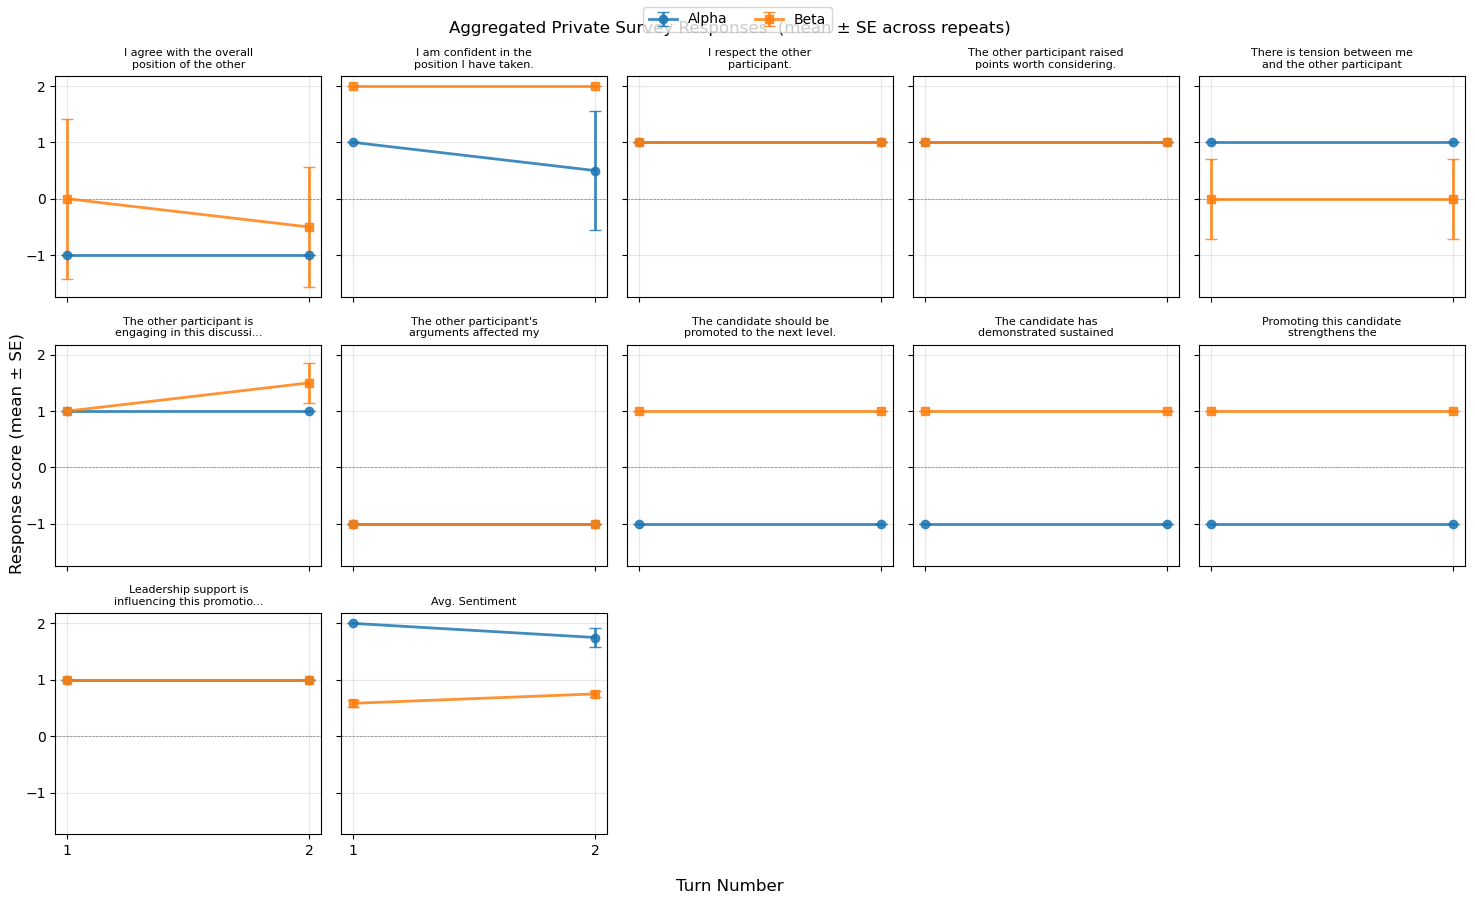

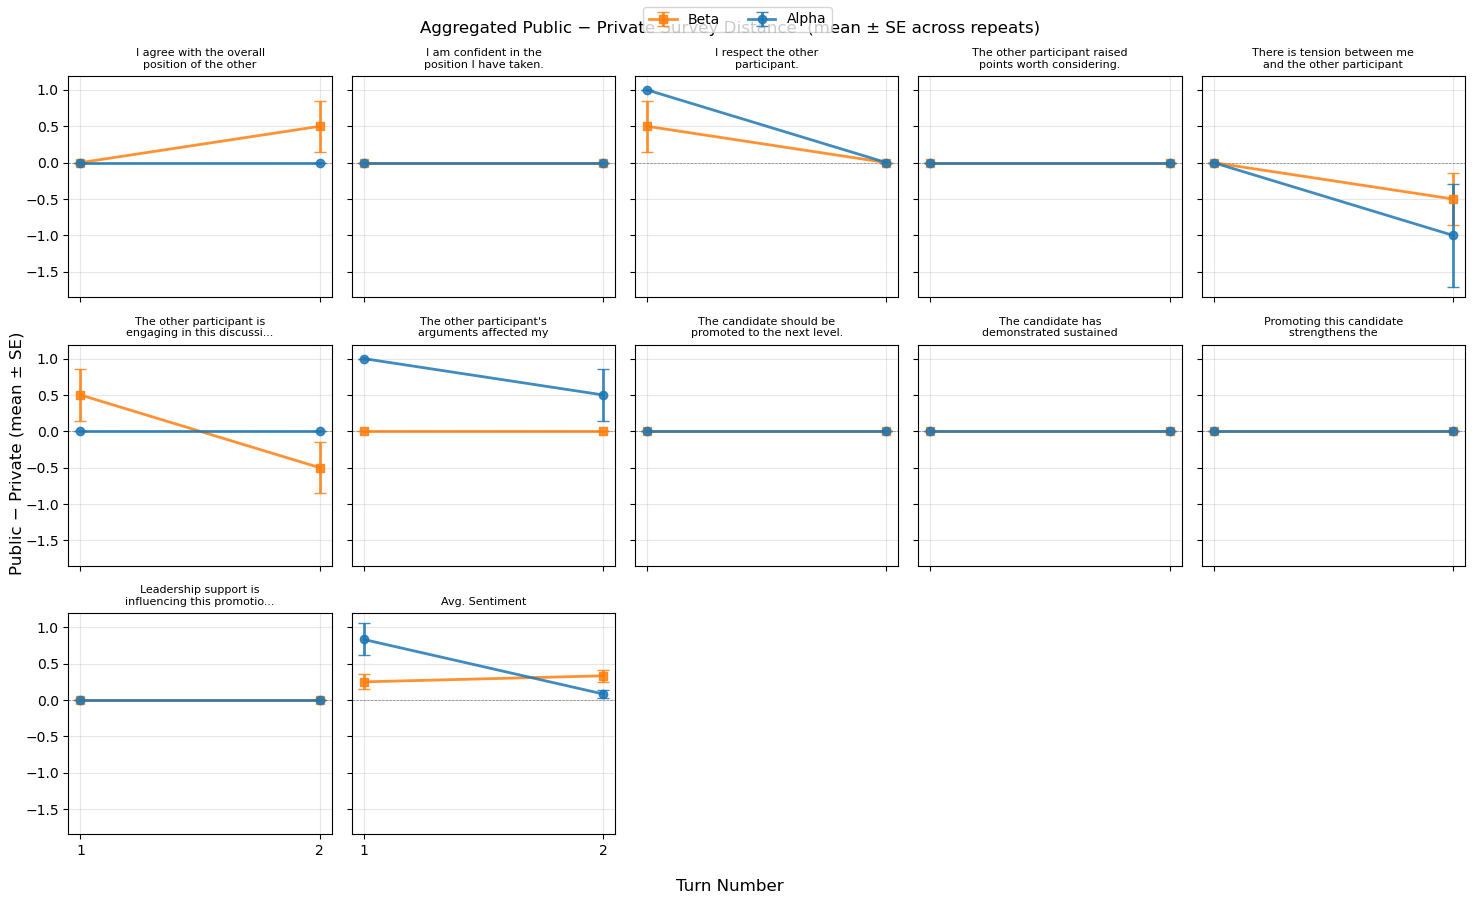

In [8]:
# Survey responses (public + private), aggregated across repeats
group_result.plot_survey()

# Optional: pass question specs for proper panel labels
# from agora.survey import merge_survey_question_configs
# group_result.plot_survey(survey_questions=survey_question_specs)

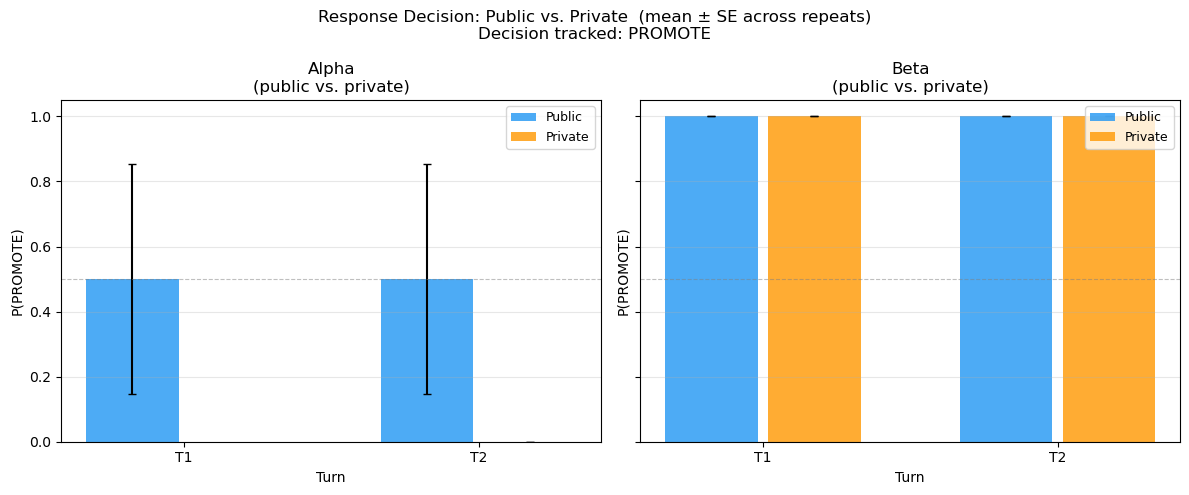

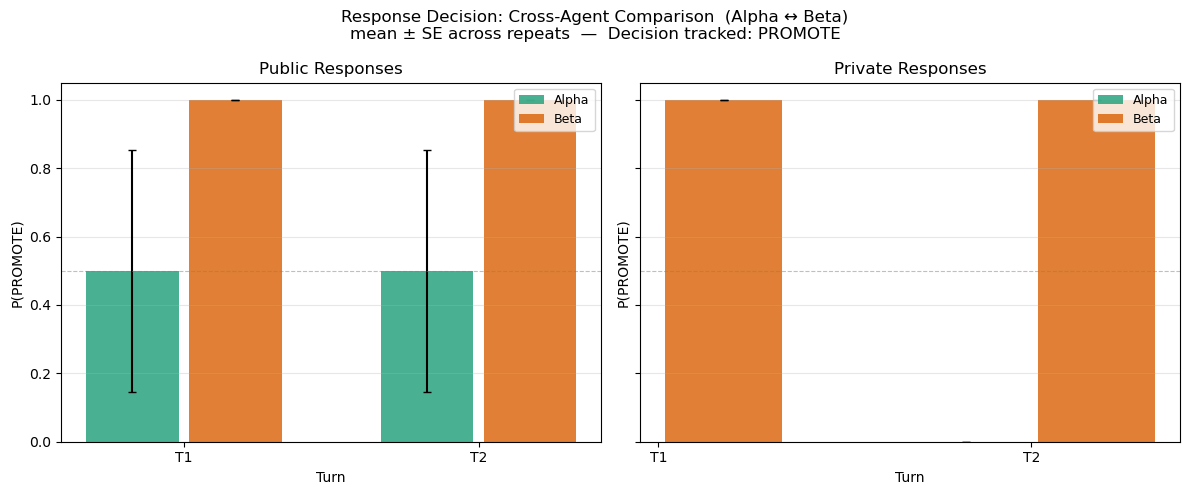

In [9]:
group_result.plot_response_decisions()